 Logistic Regression: Multiclass Classification

In [1]:
from collections import Counter
import ast
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

In [2]:
df_sample = pd.read_csv('dblp-v10.csv', nrows=5)
df_sample

,abstract,authors,n_citation,references,title,venue,year,id
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e


In [3]:
venue_counter = Counter()
for chunk in pd.read_csv('dblp-v10.csv', usecols=['venue'], chunksize=50000):
    venues = chunk['venue'].dropna().astype(str).str.strip()
    venues = venues[venues.ne('')]
    venue_counter.update(venues)

top_venues = [venue for venue, _ in venue_counter.most_common(3)]
top_venues

['international conference on acoustics, speech, and signal processing',
 'international conference on robotics and automation',
 'Lecture Notes in Computer Science']

In [4]:
def count_items(value):
    if pd.isna(value):
        return 0

    text = str(value).strip()
    if text in ('', '[]', 'nan', 'None'):
        return 0

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set, dict)):
            return len(parsed)
    except (ValueError, SyntaxError):
        pass

    cleaned = text.strip('[]')
    if not cleaned:
        return 0

    return len([item for item in cleaned.split(',') if item.strip()])

chunks = []
for chunk in pd.read_csv('dblp-v10.csv', usecols=['abstract', 'authors', 'n_citation', 'references', 'title', 'venue', 'year', 'id'], chunksize=50000, engine='python'):
    chunk = chunk.drop_duplicates().copy()
    text_columns = ['abstract', 'authors', 'references', 'title', 'venue', 'id']
    chunk[text_columns] = chunk[text_columns].fillna('')
    chunk['year'] = pd.to_numeric(chunk['year'], errors='coerce')
    chunk['n_citation'] = pd.to_numeric(chunk['n_citation'], errors='coerce')
    chunk = chunk.dropna(subset=['year', 'n_citation']).copy()
    chunk['year'] = chunk['year'].astype(int)
    chunk['reference_count'] = chunk['references'].apply(count_items)
    chunk['author_count'] = chunk['authors'].apply(count_items)
    chunk['title_length'] = chunk['title'].str.len()
    chunk['abstract_length'] = chunk['abstract'].str.len()
    chunk['venue_length'] = chunk['venue'].str.len()
    chunk = chunk[chunk['venue'].isin(top_venues)].copy()
    if not chunk.empty:
        chunks.append(chunk)

clean_df = pd.concat(chunks, ignore_index=True).drop_duplicates().copy()
clean_df['id_code'] = LabelEncoder().fit_transform(clean_df['id'])
clean_df['venue_code'] = LabelEncoder().fit_transform(clean_df['venue'])

print('Cleaned rows:', len(clean_df))
print('Duplicate rows:', clean_df.duplicated().sum())
print('Missing values per column:')
print(clean_df.isna().sum())

assert clean_df.isna().sum().sum() == 0
assert clean_df.duplicated().sum() == 0

clean_df.head()

Cleaned rows: 29863
Duplicate rows: 0
Missing values per column:
abstract           0
authors            0
n_citation         0
references         0
title              0
venue              0
year               0
id                 0
reference_count    0
author_count       0
title_length       0
abstract_length    0
venue_length       0
id_code            0
venue_code         0
dtype: int64


,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,title_length,abstract_length,venue_length,id_code,venue_code
0,We first discuss some general aspects of micro...,"['Maria Chiara Carrozza', 'Paolo Dario', 'Aria...",50,"['5ecd70e1-7ccc-4b2f-ac09-b91953cca5cd', '7fa7...",Manipulating biological and mechanical micro-o...,international conference on robotics and autom...,1998,4ab4244d-fb3e-49a3-b125-367df3d8e6ba,4,4,93,667,51,2537,2
1,A novel algorithm is presented for determining...,"['Tieniu Tan', 'Keith D. Baker', 'Geoffrey D. ...",50,"['0eb65a75-b5e8-4ff3-8e88-0b9d54708e36', '12f9...",Model-independent recovery of object orientations,international conference on robotics and autom...,1997,4abbff15-099d-4f55-b404-a99f4400984d,11,3,49,395,51,2539,2
2,This paper addresses the architecture optimiza...,"['Damien Chablat', 'Philippe Wenger']",327,"['14b3f8bf-2183-4a12-a435-97ae5b30e6b4', '173c...",Architecture optimization of a 3-DOF translati...,international conference on robotics and autom...,2003,4abe8dc6-b11f-4378-92d7-d301663832c9,9,2,112,725,51,2541,2
3,"In this paper, we use information retrieval (I...","['Xiaoqiang Xiao', 'Jasha Droppo', 'Alex Acero']",50,"['0252db2f-8ba1-47a1-b115-d90cf0a1d541', '0e29...",Information retrieval methods for automatic sp...,"international conference on acoustics, speech,...",2010,4abf915d-19a6-46c7-ba77-04b47cc740f8,10,3,62,785,68,2542,1
4,This paper investigates the use of an infinity...,"['Arati S. Deo', 'Ian D. Walker']",108,"['06a14ec6-190b-4f85-b000-ef02598e2d76', '17ab...",Minimum effort inverse kinematics for redundan...,international conference on robotics and autom...,1997,4ac1a39a-553a-489a-9479-301391d63cb8,5,2,60,981,51,2543,2


In [5]:
X = clean_df[['year', 'n_citation', 'reference_count', 'author_count', 'title_length', 'abstract_length', 'venue_length']]
y = clean_df['venue_code']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
len(X_train)

23890

In [7]:
len(X_test)

5973

In [8]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [9]:
model.score(X_test, y_test)

1.0

In [10]:
model.predict(X_test.iloc[0:5])

array([0, 1, 0, 0, 1])

Confusion Matrix

In [11]:
y_predicted = model.predict(X_test)

In [12]:
cm = confusion_matrix(y_test, y_predicted)
cm

array([[1641,    0,    0],
       [   0, 2367,    0],
       [   0,    0, 1965]], dtype=int64)

Text(95.72222222222221, 0.5, 'Truth')

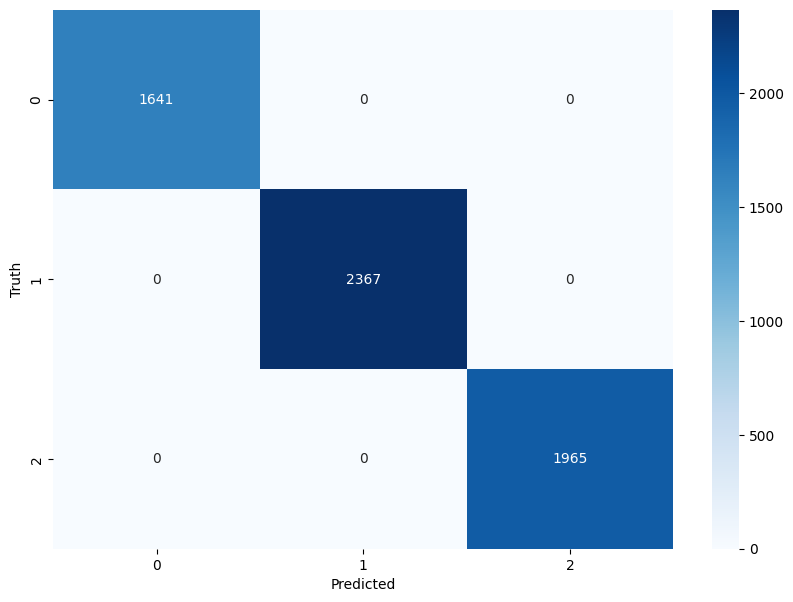

In [13]:
plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [15]:
import joblib

joblib.dump(model, 'logistic_regression_multiclass_model.joblib')
loaded_model = joblib.load('logistic_regression_multiclass_model.joblib')
